In [1]:
import pandas as pd
from autots import AutoTS
from sklearn.model_selection import train_test_split

In [2]:
# Load your dataset
df = pd.read_csv('cold-start-consumption-forecasting-training-data.csv', sep=';')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

# Sort by timestamp if not already
df.sort_values(by='timestamp', inplace=True)

# Sample your data due to its large size
# Here, we sample 10% of the data. Adjust the fraction as needed.
sampled_df = df.sample(frac=0.0001, random_state=42)

In [3]:
# Define your model
model = AutoTS(
    forecast_length=24,  # adjust based on how far you want to forecast
    frequency='H',  # 'infer' will automatically detect the frequency
    ensemble='simple',  # use a simple ensemble of models
    model_list="superfast",  # "superfast", "default", "fast_parallel"
    transformer_list="superfast",  # "superfast",
    max_generations=1,  # number of iterations for model search
    num_validations=1,  # number of validations
    validation_method="backwards",  # type of validation
)

# Fit the model
model = model.fit(
    sampled_df,
    date_col='timestamp',  # column with dates
    value_col='target',    # column with values to predict
    id_col='site_id',      # grouping (if applicable)
)

# Get the best model and predictions
prediction = model.predict()
print(prediction)

# Evaluate the model
forecast = prediction.forecast  # DataFrame of the forecast
print(forecast)
print("finished!")

Data frequency is: None, used frequency is: H
One or more series is 90% or more NaN in this train split
One or more series is 90% or more NaN in this test split
Model Number: 1 with model AverageValueNaive in generation 0 of 1


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/evaluator/metrics.py:574: RuntimeWarning: Mean of empty slice
  scaler = np.nanmean(np.abs(np.diff(df_train[-100:], axis=0)), axis=0)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/evaluator/metrics.py:575: RuntimeWarning: All-NaN slice encountered
  fill_val = np.nanmax(scaler)


Model Number: 2 with model AverageValueNaive in generation 0 of 1
Model Number: 3 with model AverageValueNaive in generation 0 of 1
Model Number: 4 with model GLS in generation 0 of 1
Model Number: 5 with model GLS in generation 0 of 1
Model Number: 6 with model LastValueNaive in generation 0 of 1
Model Number: 7 with model LastValueNaive in generation 0 of 1
Model Number: 8 with model LastValueNaive in generation 0 of 1
Model Number: 9 with model LastValueNaive in generation 0 of 1
Model Number: 10 with model SeasonalNaive in generation 0 of 1
Template Eval Error: Exception('Transformer PowerTransformer failed on fit') in model 10 in generation 0: SeasonalNaive
Model Number: 11 with model SeasonalNaive in generation 0 of 1


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:3312: RuntimeWarning: overflow encountered in power
  out[~pos] = -(np.power(-x[~pos] + 1, 2 - lmbda) - 1) / (2 - lmbda)


Model Number: 12 with model SeasonalNaive in generation 0 of 1
Model Number: 13 with model ConstantNaive in generation 0 of 1
Template Eval Error: Exception('Transformer PowerTransformer failed on fit') in model 13 in generation 0: ConstantNaive
Model Number: 14 with model SeasonalNaive in generation 0 of 1
Model Number: 15 with model SeasonalNaive in generation 0 of 1


...

Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/tools/transform.py", line 4732, in _fit
    df = self._fit_one(df, i)
         ^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/tools/transform.py", line 4716, in _fit_one
    df = self.transformers[i].fit_transform(df)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/_set_output.py", line 157, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/evaluator/metrics.py:574: RuntimeWarning: Mean of empty slice
  scaler = np.nanmean(np.abs(np.diff(df_train[-100:], axis=0)), axis=0)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/evaluator/metrics.py:575: RuntimeWarning: All-NaN slice encountered
  fill_val = np.nanmax(scaler)


Model Number: 96 with model Ensemble in generation 3 of Ensembles
Model Number: 97 with model Ensemble in generation 3 of Ensembles
Model Number: 98 with model Ensemble in generation 3 of Ensembles
Model Number: 99 with model Ensemble in generation 3 of Ensembles
Model Number: 100 with model Ensemble in generation 3 of Ensembles
Template Eval Error: ValueError('BestN failed, no component models available.') in model 100 in generation 3: Ensemble
Validation Round: 1
One or more series is 90% or more NaN in this train split
One or more series is 90% or more NaN in this test split
Model Number: 1 of 6 with model Ensemble for Validation 1


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/evaluator/metrics.py:574: RuntimeWarning: Mean of empty slice
  scaler = np.nanmean(np.abs(np.diff(df_train[-100:], axis=0)), axis=0)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/evaluator/metrics.py:575: RuntimeWarning: All-NaN slice encountered
  fill_val = np.nanmax(scaler)


1 - Ensemble with avg smape nan: 
Model Number: 2 of 6 with model Ensemble for Validation 1
2 - Ensemble with avg smape nan: 
Model Number: 3 of 6 with model Ensemble for Validation 1
3 - Ensemble with avg smape nan: 
Model Number: 4 of 6 with model Ensemble for Validation 1
4 - Ensemble with avg smape nan: 
Model Number: 5 of 6 with model Ensemble for Validation 1
5 - Ensemble with avg smape nan: 
Model Number: 6 of 6 with model Ensemble for Validation 1
Template Eval Error: ValueError('BestN failed, no component models available.') in model 6 in generation 0: Ensemble
Prediction object: 
Return .forecast, 
 .upper_forecast, 
 .lower_forecast 
 .model_parameters 
 .transformation_parameters
site_id                            1              2            3   \
2017-10-01 14:00:00+00:00  553.308046  247223.247176  6182.639077   
2017-10-01 15:00:00+00:00  553.308046  247223.247176  6182.639077   
2017-10-01 16:00:00+00:00  553.308046  247223.247176  6182.639077   
2017-10-01 17:00:00+00:

In [4]:
print(model.best_model_name)
print(model.best_model_params)
print(model.best_model_transformation_params)

GLS
{}
{'fillna': 'median', 'transformations': {'0': 'ClipOutliers', '1': 'QuantileTransformer', '2': 'RobustScaler', '3': 'Round', '4': 'MaxAbsScaler'}, 'transformation_params': {'0': {'method': 'clip', 'std_threshold': 3.5, 'fillna': None}, '1': {'output_distribution': 'uniform', 'n_quantiles': 1000}, '2': {}, '3': {'model': 'middle', 'decimals': 2, 'on_transform': True, 'on_inverse': True}, '4': {}}}


<Axes: >

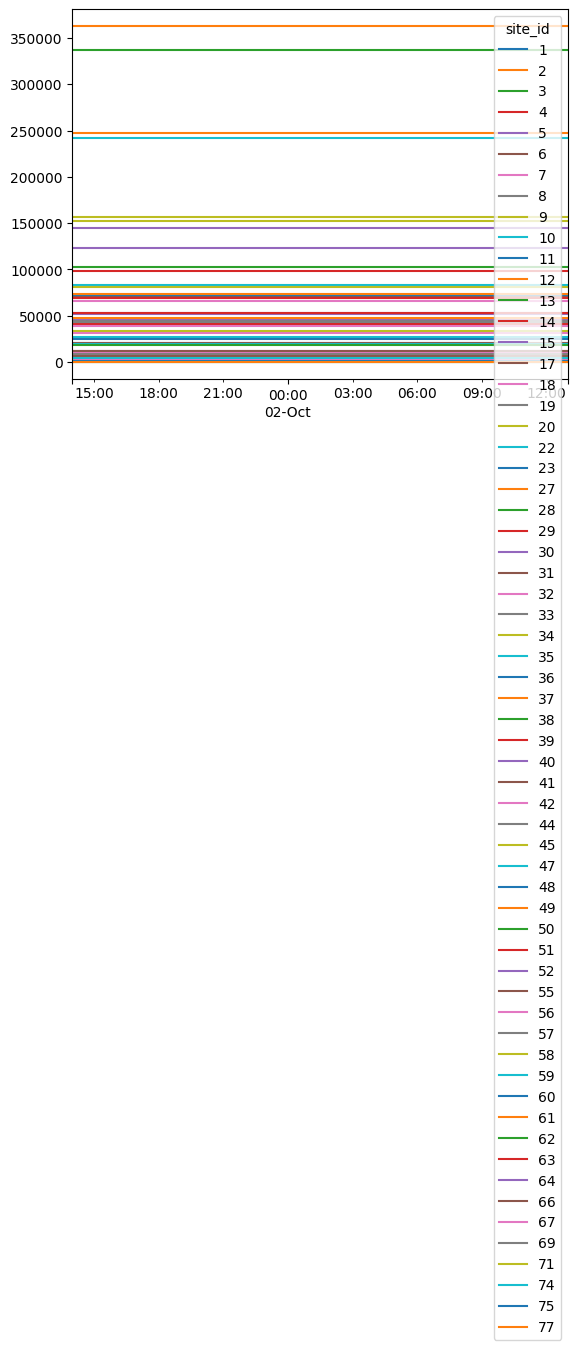

In [5]:
forecast.plot()

## Attempt with only 1 building (site_id=2)

In [6]:
df = pd.read_csv("cold-start-consumption-forecasting-training-data.csv", sep=";", parse_dates=['timestamp'])
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df.sort_values(by='timestamp', inplace=True)

In [7]:
df2 = df[df["site_id"]==2]
df2 = df2.drop(['obs_id'], axis=1)

In [25]:
df2

,site_id,timestamp,temperature,temperature_-1,temperature_-2,load,load_-1,load_-2,target
1221786,2,2013-01-01 03:00:00+00:00,0.500000,1.000000,1.000000,52561.679251,51033.723459,49964.154405,53631.248306
29192,2,2013-01-01 04:00:00+00:00,0.500000,0.500000,1.000000,55159.204098,52561.679251,51033.723459,62340.596321
56052,2,2013-01-01 05:00:00+00:00,0.000000,0.500000,0.500000,58979.093579,55159.204098,52561.679251,106345.723136
1332108,2,2013-01-01 06:00:00+00:00,0.000000,0.000000,0.500000,58520.706841,58979.093579,55159.204098,132473.767183
1063812,2,2013-01-01 07:00:00+00:00,0.000000,0.000000,0.000000,59590.275895,58520.706841,58979.093579,160129.767021
...,...,...,...,...,...,...,...,...,...
438680,2,2014-08-24 22:00:00+00:00,18.000000,18.500000,20.166667,65396.507906,66771.668119,65854.894643,173117.391255
438681,2,2014-08-24 23:00:00+00:00,17.933333,18.000000,18.500000,66313.281381,65396.507906,66771.668119,177854.054211
359458,2,2014-08-25 00:00:00+00:00,18.000000,17.933333,18.000000,72730.695708,66313.281381,65396.507906,172200.617780
1054107,2,2014-08-25 01:00:00+00:00,17.000000,18.000000,17.933333,77314.563085,72730.695708,66313.281381,170978.253146


In [8]:
train2 = df2[:2000]
valid2 = df2[2000:2024]

In [9]:
train2

,site_id,timestamp,temperature,temperature_-1,temperature_-2,load,load_-1,load_-2,target
1221786,2,2013-01-01 03:00:00+00:00,0.500000,1.000000,1.000000,52561.679251,51033.723459,49964.154405,53631.248306
29192,2,2013-01-01 04:00:00+00:00,0.500000,0.500000,1.000000,55159.204098,52561.679251,51033.723459,62340.596321
56052,2,2013-01-01 05:00:00+00:00,0.000000,0.500000,0.500000,58979.093579,55159.204098,52561.679251,106345.723136
1332108,2,2013-01-01 06:00:00+00:00,0.000000,0.000000,0.500000,58520.706841,58979.093579,55159.204098,132473.767183
1063812,2,2013-01-01 07:00:00+00:00,0.000000,0.000000,0.000000,59590.275895,58520.706841,58979.093579,160129.767021
...,...,...,...,...,...,...,...,...,...
58662,2,2013-03-25 06:00:00+00:00,4.000000,4.500000,4.133333,205051.667312,146072.573733,81592.839303,200926.186673
1221916,2,2013-03-25 07:00:00+00:00,4.033333,4.000000,4.500000,237597.125685,205051.667312,146072.573733,223387.136818
305668,2,2013-03-25 08:00:00+00:00,4.000000,4.033333,4.000000,259446.893514,237597.125685,205051.667312,244931.313488
804135,2,2013-03-25 09:00:00+00:00,4.500000,4.000000,4.033333,270906.561955,259446.893514,237597.125685,264794.738786


In [10]:
model = AutoTS(
    forecast_length=24, #next 24 hours  
    frequency='H',  #H=hours
    ensemble='simple',  # use a simple ensemble of models
    model_list="default",  
    transformer_list="fast",  
    max_generations=1,  
    num_validations=1,  
    validation_method="backwards",  # type of validation
)

# Fit the model
model = model.fit(
    train2,
    date_col='timestamp',  # column with dates
    value_col='target',    # column with values to predict
    id_col='site_id',      
)

# Get the best model and predictions
prediction = model.predict()
print(prediction)

# Evaluate the model
forecast = prediction.forecast  # DataFrame of the forecast
print(forecast)
print("finished!")

Data frequency is: H, used frequency is: H
Model Number: 1 with model ARIMA in generation 0 of 1
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           17     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.08584D+01    |proj g|=  6.01893D-02

At iterate    1    f=  1.08537D+01    |proj g|=  2.68161D-02


 This problem is unconstrained.



At iterate    2    f=  1.08511D+01    |proj g|=  1.93101D-02

At iterate    3    f=  1.08499D+01    |proj g|=  1.73427D-02

At iterate    4    f=  1.08494D+01    |proj g|=  1.51235D-02

At iterate    5    f=  1.08490D+01    |proj g|=  7.73540D-03

At iterate    6    f=  1.08488D+01    |proj g|=  5.28847D-03

At iterate    7    f=  1.08486D+01    |proj g|=  6.86259D-03

At iterate    8    f=  1.08483D+01    |proj g|=  1.25730D-02

At iterate    9    f=  1.08479D+01    |proj g|=  5.67498D-03

At iterate   10    f=  1.08475D+01    |proj g|=  7.95263D-03

At iterate   11    f=  1.08473D+01    |proj g|=  1.65762D-02

At iterate   12    f=  1.08471D+01    |proj g|=  2.61191D-02

At iterate   13    f=  1.08468D+01    |proj g|=  1.25160D-02

At iterate   14    f=  1.08464D+01    |proj g|=  7.81849D-03

At iterate   15    f=  1.08461D+01    |proj g|=  1.91974D-02

At iterate   16    f=  1.08459D+01    |proj g|=  7.03560D-03

At iterate   17    f=  1.08458D+01    |proj g|=  3.49639D-03

At iter

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Model Number: 8 with model DatepartRegression in generation 0 of 1
Epoch 1/50
62/62 [==============================] - 2s 1ms/step - loss: 0.3682
Epoch 2/50
62/62 [==============================] - 0s 1ms/step - loss: 0.3046
Epoch 3/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2810
Epoch 4/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2747
Epoch 5/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2604
Epoch 6/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2567
Epoch 7/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2467
Epoch 8/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2455
Epoch 9/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2378
Epoch 10/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2336
Epoch 11/50
62/62 [==============================] - 0s 1ms/step - loss: 0.2289
Epoch 12/50
62/62 [==============================] - 0s 1ms/st

...


At iterate    2    f=  1.08491D+01    |proj g|=  2.22900D-02

At iterate    3    f=  1.08474D+01    |proj g|=  2.03983D-02

At iterate    4    f=  1.08470D+01    |proj g|=  1.86454D-02

At iterate    5    f=  1.08465D+01    |proj g|=  8.23148D-03

At iterate    6    f=  1.08464D+01    |proj g|=  5.14624D-03

At iterate    7    f=  1.08461D+01    |proj g|=  7.63740D-03

At iterate    8    f=  1.08459D+01    |proj g|=  1.04144D-02

At iterate    9    f=  1.08455D+01    |proj g|=  4.59328D-03

At iterate   10    f=  1.08453D+01    |proj g|=  4.69782D-03

At iterate   11    f=  1.08451D+01    |proj g|=  9.82967D-03

At iterate   12    f=  1.08449D+01    |proj g|=  1.64086D-02

At iterate   13    f=  1.08447D+01    |proj g|=  2.29444D-02

At iterate   14    f=  1.08443D+01    |proj g|=  1.37512D-02

At iterate   15    f=  1.08439D+01    |proj g|=  9.48441D-03

At iterate   16    f=  1.08434D+01    |proj g|=  9.67387D-03

At iterate   17    f=  1.08432D+01    |proj g|=  9.42223D-03

At iter

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/models/sklearn.py:178: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/autots/models/sklearn.py:178: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')


30 - ETS with avg smape 38.72: 
Model Number: 31 of 48 with model NVAR for Validation 1
31 - NVAR with avg smape 55.25: 
Model Number: 32 of 48 with model NVAR for Validation 1
32 - NVAR with avg smape 28.12: 
Model Number: 33 of 48 with model ETS for Validation 1
33 - ETS with avg smape 33.19: 
Model Number: 34 of 48 with model NVAR for Validation 1
34 - NVAR with avg smape 27.99: 
Model Number: 35 of 48 with model UnobservedComponents for Validation 1
35 - UnobservedComponents with avg smape 33.18: 
Model Number: 36 of 48 with model SeasonalNaive for Validation 1
36 - SeasonalNaive with avg smape 83.57: 
Model Number: 37 of 48 with model GLM for Validation 1
37 - GLM with avg smape 33.35: 
Model Number: 38 of 48 with model UnobservedComponents for Validation 1
38 - UnobservedComponents with avg smape 77.74: 
Model Number: 39 of 48 with model GLS for Validation 1
39 - GLS with avg smape 77.74: 
Model Number: 40 of 48 with model GLM for Validation 1
40 - GLM with avg smape 77.74: 
Mode

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Model Number: 369 with model Ensemble in generation 3 of Ensembles
Model Number: 370 with model Ensemble in generation 3 of Ensembles
Model Number: 371 with model Ensemble in generation 3 of Ensembles
Model Number: 372 with model Ensemble in generation 3 of Ensembles
Model Number: 373 with model Ensemble in generation 3 of Ensembles
Model Number: 374 with model Ensemble in generation 3 of Ensembles
Model Number: 375 with model Ensemble in generation 3 of Ensembles
Validation Round: 1
Model Number: 1 of 8 with model Ensemble for Validation 1
📈 1 - Ensemble with avg smape 4.74: 
Model Number: 2 of 8 with model Ensemble for Validation 1
2 - Ensemble with avg smape 5.17: 
Model Number: 3 of 8 with model Ensemble for Validation 1
3 - Ensemble with avg smape 8.88: 
Model Number: 4 of 8 with model Ensemble for Validation 1
4 - Ensemble with avg smape 5.26: 
Model Number: 5 of 8 with model Ensemble for Validation 1
5 - Ensemble with avg smape 10.48: 
Model Number: 6 of 8 with model Ensemble fo

In [12]:
import numpy as np
pred = forecast[2]
pred = np.array(pred)
pred

array([249016.26769325, 254691.54872075, 253200.66788681, 254797.32403814,
       255578.25014692, 246544.99351945, 245434.53938487, 223399.73131557,
       186725.86083195, 199247.26714062, 196384.22147284, 177514.84802499,
       181811.45971262, 170893.97116297, 172600.11822155, 173668.98329605,
       157286.24129219, 175015.11234896, 183291.18009465, 198464.57170341,
       228386.60817014, 246943.29164218, 260386.35724435, 259808.15428137])

In [15]:
ground = valid2["target"]
ground = np.array(ground)
ground

array([248751.20296844, 258071.7333008 , 263725.1697319 , 255932.59519173,
       248598.40738923, 236985.94336859, 233471.64504655, 205204.46289104,
       170214.27524991, 181368.35253289, 175867.71168101, 163949.65650193,
       174492.55146804, 167463.95482396, 168278.8645798 , 167463.95482396,
       139196.77266846, 124833.98822188, 146683.75605019, 198634.25298463,
       240958.62842828, 254557.43497876, 264183.55646956, 264489.147628  ])

In [ ]:
len(ground)

In [16]:
from sklearn.metrics import mean_squared_error

In [17]:
mse = mean_squared_error(pred, ground)
np.sqrt(mse)

16451.224018999306

In [18]:
from sklearn.metrics import r2_score

# Assuming pred is your predictions and ground is your ground truth values
r2 = r2_score(ground, pred)

n = len(ground)  # Number of observations
p = 6  # Number of predictors in your model

# Adjusted R^2 calculation
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R-squared Score:", adjusted_r2)

Adjusted R-squared Score: 0.8201026178994335


In [1]:
print(model.best_model_name)
model.best_model_params
#print(model.best_model_transformation_params)

NameError: name 'model' is not defined

### Optimal model:

In [ ]:
DatepartRegression

<Axes: title={'center': '2 with model BestN'}>

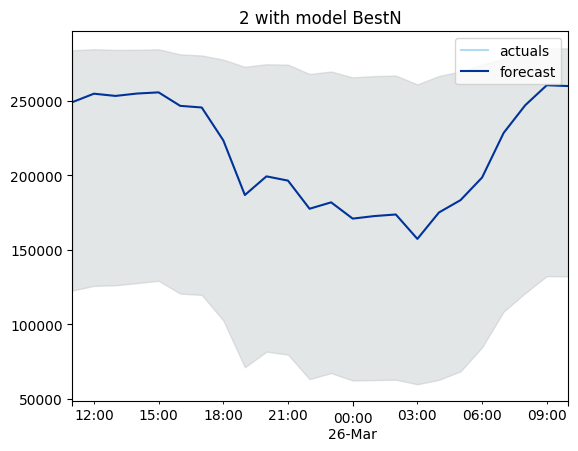

In [24]:
prediction.plot()

## Attempt with 

In [26]:
df2 = df[df["site_id"]==2]
df2 = df2.drop(['obs_id'], axis=1)
train2 = df2[:-24]
valid2 = df2[-24:]

In [33]:
# Define your model
model = AutoTS(
    forecast_length=24,  # adjust based on how far you want to forecast
    frequency='H',  # 'infer' will automatically detect the frequency
    ensemble='simple',  # use a simple ensemble of models
    model_list="default",  # "superfast", "default", "fast_parallel"
    transformer_list="superfast",  # "superfast",
    max_generations=1,  # number of iterations for model search
    num_validations=1,  # number of validations
    validation_method="backwards",  # type of validation
)

# Fit the model
model = model.fit(
    train2,
    date_col='timestamp',  # column with dates
    value_col='target',    # column with values to predict
    id_col='site_id',      # grouping (if applicable)
)

# Get the best model and predictions
prediction = model.predict()
print(prediction)

# Evaluate the model
forecast = prediction.forecast  # DataFrame of the forecast
print(forecast)
print("finished!")

Data frequency is: H, used frequency is: H
Model Number: 1 with model ARIMA in generation 0 of 1


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           17     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.09344D+01    |proj g|=  4.25758D-02

At iterate    1    f=  1.09306D+01    |proj g|=  2.86714D-02

At iterate    2    f=  1.09292D+01    |proj g|=  1.64552D-02

At iterate    3    f=  1.09277D+01    |proj g|=  1.19781D-02

At iterate    4    f=  1.09269D+01    |proj g|=  1.13415D-02

At iterate    5    f=  1.09267D+01    |proj g|=  1.03303D-02

At iterate    6    f=  1.09266D+01    |proj g|=  4.82664D-03

At iterate    7    f=  1.09265D+01    |proj g|=  5.76592D-03

At iterate    8    f=  1.09264D+01    |proj g|=  6.88976D-03

At iterate    9    f=  1.09262D+01    |proj g|=  7.80060D-03

At iterate   10    f=  1.09261D+01    |proj g|=  8.34055D-03

At iterate   11    f=  1.09260D+01    |proj g|=  5.16205D-03

At iterate   12    f=  1.09258D+01    |proj g|=  5.21981D-03

At iterate   13    f=  1.0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Model Number: 7 with model DatepartRegression in generation 0 of 1


...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Model Number: 370 with model Ensemble in generation 3 of Ensembles
Epoch 1/50
450/450 [==============================] - 2s 1ms/step - loss: 0.3204
Epoch 2/50
450/450 [==============================] - 0s 1ms/step - loss: 0.2823
Epoch 3/50
450/450 [==============================] - 0s 1ms/step - loss: 0.2484
Epoch 4/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1867
Epoch 5/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1478
Epoch 6/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1356
Epoch 7/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1288
Epoch 8/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1222
Epoch 9/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1216
Epoch 10/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1176
Epoch 11/50
450/450 [==============================] - 0s 1ms/step - loss: 0.1148
Epoch 12/50
450/450 [===================

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


📈 2 - Ensemble with avg smape 5.96: 
Model Number: 3 of 8 with model Ensemble for Validation 1
Epoch 1/50
449/449 [==============================] - 2s 1ms/step - loss: 0.3230
Epoch 2/50
449/449 [==============================] - 0s 1ms/step - loss: 0.2866
Epoch 3/50
449/449 [==============================] - 1s 1ms/step - loss: 0.2676
Epoch 4/50
449/449 [==============================] - 0s 1ms/step - loss: 0.2310
Epoch 5/50
449/449 [==============================] - 0s 1ms/step - loss: 0.1871
Epoch 6/50
449/449 [==============================] - 0s 1ms/step - loss: 0.1542
Epoch 7/50
449/449 [==============================] - 0s 1ms/step - loss: 0.1427
Epoch 8/50
449/449 [==============================] - 0s 1ms/step - loss: 0.1320
Epoch 9/50
449/449 [==============================] - 0s 1ms/step - loss: 0.1264
Epoch 10/50
449/449 [==============================] - 0s 1ms/step - loss: 0.1225
Epoch 11/50
449/449 [==============================] - 1s 1ms/step - loss: 0.1202
Epoch 12/50


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [34]:
pred = forecast[2]
pred = np.array(pred)
ground = valid2["target"]
ground = np.array(ground)

In [35]:
ground

array([ 73036.28686666,  75481.01613416, 167769.5459824 , 189160.92707306,
       244472.92675031, 249820.77202298, 255015.82171642, 259141.30235533,
       245848.08696328, 249667.97644376, 259599.68909299, 271670.53985129,
       272892.90448504, 244320.13117109, 246000.8825425 , 249667.97644376,
       198175.86624697, 218192.08712465, 202454.1424651 , 173117.39125507,
       177854.05421085, 172200.61777975, 170978.253146  , 174492.55146804])

In [36]:
mse = mean_squared_error(pred, ground)
np.sqrt(mse)

28843.0736875497

In [37]:
# Assuming pred is your predictions and ground is your ground truth values
r2 = r2_score(ground, pred)

n = len(ground)  # Number of observations
p = 6  # Number of predictors in your model

# Adjusted R^2 calculation
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R-squared Score:", adjusted_r2)

Adjusted R-squared Score: 0.6156494136675139
